In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
(x_train,y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

x_train = pad_sequences(x_train, padding="post", truncating="post", maxlen=100)
x_test = pad_sequences(x_test, padding= "post", truncating="post", maxlen=100)


In [3]:
model = Sequential()
model.add(Embedding(10000, 32,input_length=100))
model.add(Bidirectional(SimpleRNN(5)))
model.add(Dense(1,activation="sigmoid"))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 32)           320000    
                                                                 
 bidirectional (Bidirectiona  (None, 10)               380       
 l)                                                              
                                                                 
 dense (Dense)               (None, 1)                 11        
                                                                 
Total params: 320,391
Trainable params: 320,391
Non-trainable params: 0
_________________________________________________________________


In [4]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


In [7]:
from keras.callbacks import EarlyStopping
callback = EarlyStopping(monitor="loss", patience=1,restore_best_weights=True)

In [8]:
history = model.fit(x_train,y_train,validation_batch_size=32,validation_split=0.2, epochs=5,callbacks=callback)

Epoch 1/5


625/625 [==============================] - 79s 126ms/step - loss: 0.6011 - accuracy: 0.6920 - val_loss: 0.6017 - val_accuracy: 0.6928
Epoch 2/5
625/625 [==============================] - 76s 121ms/step - loss: 0.4236 - accuracy: 0.8188 - val_loss: 0.5818 - val_accuracy: 0.7304
Epoch 3/5
625/625 [==============================] - 119s 191ms/step - loss: 0.2534 - accuracy: 0.9093 - val_loss: 0.6329 - val_accuracy: 0.7152
Epoch 4/5
625/625 [==============================] - 132s 211ms/step - loss: 0.1467 - accuracy: 0.9580 - val_loss: 0.6967 - val_accuracy: 0.7236
Epoch 5/5
625/625 [==============================] - 131s 209ms/step - loss: 0.0917 - accuracy: 0.9772 - val_loss: 0.8175 - val_accuracy: 0.6964


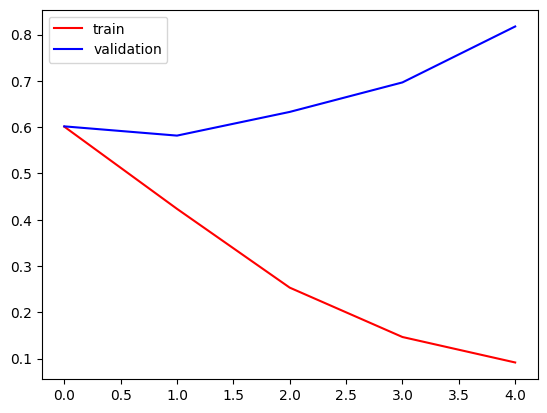

In [9]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

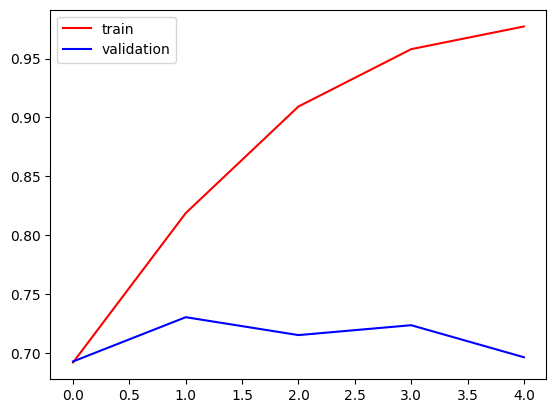

In [10]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()